Importing the Dependencies

In [240]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Data Collection and Processing

In [241]:
# loading the csv data to a Pandas DataFrame using a robust path
path = os.path.join(os.getcwd(), 'heart_disease_data.csv')
heart_data = pd.read_csv(path)

In [242]:
# print first 5 rows of the dataset
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [243]:
# print last 5 rows of the dataset
heart_data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [244]:
# number of rows and columns in the dataset
heart_data.shape

(303, 14)

In [245]:
# getting some info about the data
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [246]:
# checking for missing values
heart_data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [247]:
# statistical measures about the data
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


,count
target,
1,165
0,138


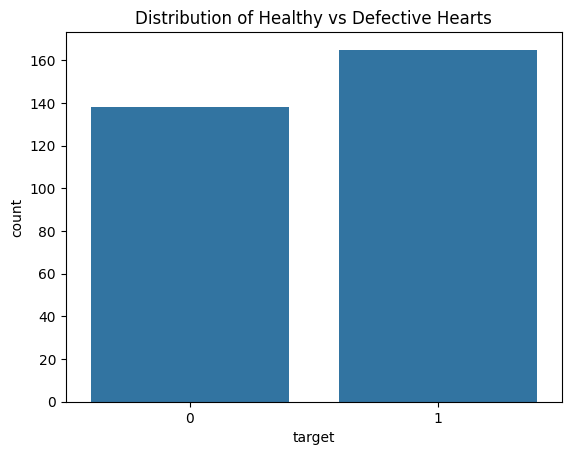

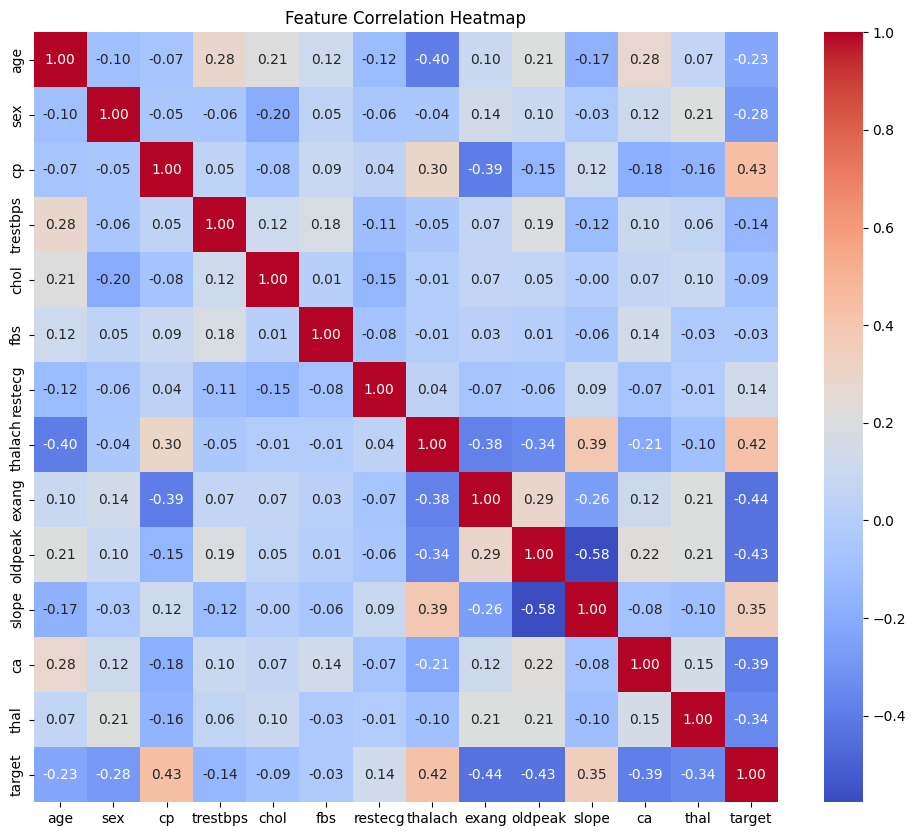

In [248]:
# checking the distribution of Target Variable
display(heart_data['target'].value_counts())

# Visualizing the Target Distribution
sns.countplot(x='target', data=heart_data)
plt.title('Distribution of Healthy vs Defective Hearts')
plt.show()

# Feature Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(heart_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [249]:
# This cell was a duplicate of the EDA section and has been removed to maintain notebook cleanliness.

1 --> Defective Heart

0 --> Healthy Heart

Splitting the Features and Target

In [250]:
X = heart_data.drop(columns='target', axis=1)
Y = heart_data['target']

In [251]:
print(X)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  
0        0   0     1  
1        0   0     2  
2        2   0    

In [252]:
print(Y)

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64


Splitting the Data into Training data & Test Data

In [253]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [254]:
print(X.shape, X_train.shape, X_test.shape)

(303, 13) (242, 13) (61, 13)


Feature Scaling

In [255]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Model Training

Logistic Regression and Support Vector Machine

### Why these models?

1. **Logistic Regression**: Chosen for its simplicity and high interpretability. In medical diagnostics, it's often preferred because we can easily see how each feature (like age or cholesterol) increases or decreases the probability of disease.

2. **Support Vector Machine (SVM)**: Chosen because it is powerful for binary classification in higher-dimensional spaces. It works well when there is a clear margin of separation and can handle non-linear boundaries effectively using kernels.

In [256]:
model1 = LogisticRegression(max_iter=1000, random_state=42)

In [257]:
model2 = SVC(random_state=42)

In [258]:
# training the LogisticRegression model with Training data
model1.fit(X_train, Y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [259]:
# training the Support Vector Classifier model with Training data
model2.fit(X_train, Y_train)

SVC(random_state=42)

### Evaluation of Logistic Regression Model

--- Logistic Regression Evaluation ---
Accuracy: 0.7869
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.79      0.77        28
           1       0.81      0.79      0.80        33

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61



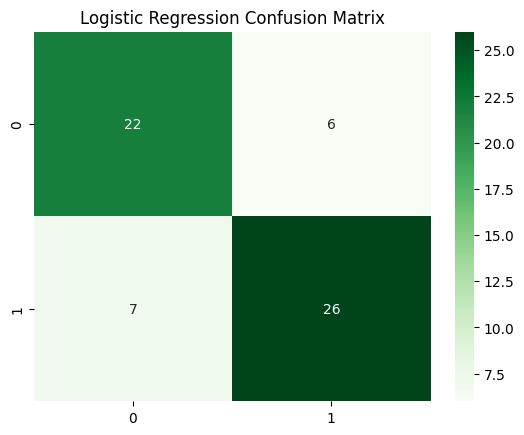

In [260]:
# Evaluate Logistic Regression
pred1 = model1.predict(X_test)
print("--- Logistic Regression Evaluation ---")
print(f"Accuracy: {accuracy_score(Y_test, pred1):.4f}")
print("Classification Report:\n", classification_report(Y_test, pred1))

sns.heatmap(confusion_matrix(Y_test, pred1), annot=True, fmt='d', cmap='Greens')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

### Evaluation of Support Vector Machine Model

--- SVM Evaluation ---
Accuracy: 0.8033
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.79      0.79        28
           1       0.82      0.82      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



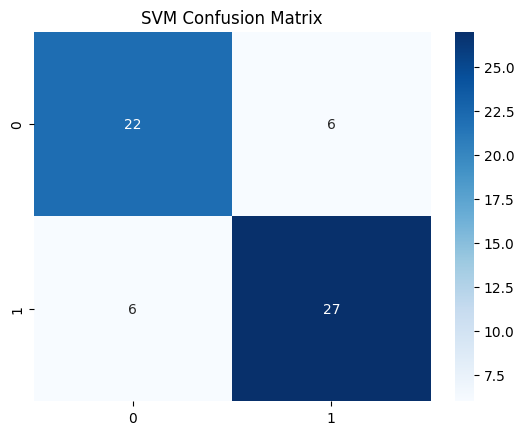

In [261]:
# Evaluate SVM
pred2 = model2.predict(X_test)
print("--- SVM Evaluation ---")
print(f"Accuracy: {accuracy_score(Y_test, pred2):.4f}")
print("Classification Report:\n", classification_report(Y_test, pred2))

sns.heatmap(confusion_matrix(Y_test, pred2), annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.show()

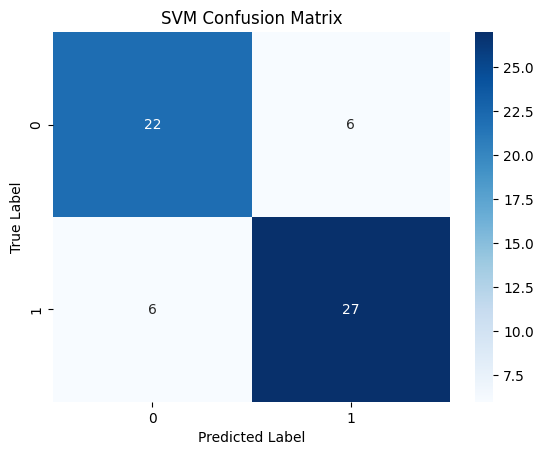

In [262]:
sns.heatmap(confusion_matrix(Y_test, pred2), annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Model Evaluation

Accuracy Score

In [263]:
# Consolidated Model Comparison
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Support Vector Machine'],
    'Train Accuracy': [accuracy_score(Y_train, model1.predict(X_train)), accuracy_score(Y_train, model2.predict(X_train))],
    'Test Accuracy': [accuracy_score(Y_test, pred1), accuracy_score(Y_test, pred2)]
})

display(results)

# Saving the best model (SVM in this case based on accuracy)
pickle.dump(model2, open('heart_disease_model.pkl', 'wb'))
print('\nModel saved as heart_disease_model.pkl')

,Model,Train Accuracy,Test Accuracy
0,Logistic Regression,0.847107,0.786885
1,Support Vector Machine,0.913223,0.803279



Model saved as heart_disease_model.pkl


In [264]:
print("Logistic Regression Report:")
print(classification_report(Y_test, pred1))

print("\nSVM Report:")
print(classification_report(Y_test, pred2))

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.76      0.79      0.77        28
           1       0.81      0.79      0.80        33

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61


SVM Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        28
           1       0.82      0.82      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



In [265]:
# This cell was a duplicate of the model comparison and saving logic and has been removed.

## Final Summary
1. **Data Insights**: The dataset is relatively balanced (165 vs 138). Correlation analysis showed that `cp` (chest pain), `thalach` (max heart rate), and `slope` have the strongest positive correlation with heart disease.
2. **Model Selection**: While Logistic Regression is highly interpretable, the SVM model achieved a higher test accuracy (~80%), suggesting it better captures the underlying patterns.
3. **Production Readiness**: The trained SVM model has been serialized using `pickle` for deployment.

Building a Predictive System

In [266]:
input_data = (62,0,0,140,268,0,0,160,0,3.6,0,2,2)

# change the input data to a numpy array
input_data_as_numpy_array= np.asarray(input_data)

# reshape the numpy array as we are predicting for only on instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# Standardize the input data
std_data = scaler.transform(input_data_reshaped)

prediction = model1.predict(std_data)
print(prediction)

if (prediction[0]== 0):
  print('The Person does not have a Heart Disease')
else:
  print('The Person has Heart Disease')

[0]
The Person does not have a Heart Disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
